# AI Slop vs Structured Text: Internal Degradation Map

**Four signals measured in a single forward pass — no training needed.**

| Signal | What it measures | Slop prediction |
|---|---|---|
| Participation Ratio (PR) | Effective rank of hidden states | Collapses earlier |
| Gini coefficient | Activation concentration | Higher at late layers |
| Logit lens depth | Layer at which final token locks in | Locks in earlier |
| Attention entropy | How diffuse vs focused each head is | Sinks earlier |

Target: `Qwen/Qwen2.5-0.5B`. Runs in ~2 min on a T4 Colab GPU.

In [ ]:
!pip install -q transformers accelerate matplotlib

## Cell 2 — Config
Change `MODEL_ID` here if you want to run on a larger model.

In [ ]:
MODEL_ID = "Qwen/Qwen2.5-0.5B"   # swap to Qwen2.5-3B if you have >=16GB VRAM

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if DEVICE == "cuda" else torch.float32
print(f"Device: {DEVICE}, dtype: {DTYPE}")


Device: cuda, dtype: torch.float16


## Cell 3 — Text Specimens
Four points on the information-density axis:
- **slop**: high fluency, low semantic content, stationary n-gram statistics
- **wiki**: normal English, moderate information density
- **technical**: OMP/compressed sensing, dense terminology
- **sanskrit**: transliterated Sanskrit, every noun carries explicit case/role/number

In [ ]:
TEXTS = {
    "slop": (
        "The importance of success cannot be overstated. "
        "Success is something that everyone wants to achieve. "
        "Achieving success requires hard work and dedication. "
        "Hard work and dedication are the keys to success. "
        "Success comes to those who work hard every single day. "
        "Every day is an opportunity to be successful and achieve your goals. "
        "Your goals define your path to success in life."
    ),
    "wiki": (
        "The French Revolution was a period of radical political and societal "
        "change in France that began with the Estates General of 1789 and ended "
        "with the formation of the French Consulate in November 1799. Many of its "
        "ideas are considered fundamental principles of liberal democracy, while the "
        "values and institutions it created are at the foundation of modern France."
    ),
    "technical": (
        "Orthogonal Matching Pursuit recovers a k-sparse signal x from underdetermined "
        "measurements y = Phi x by greedily selecting the dictionary column most "
        "correlated with the current residual, projecting the measurements onto the "
        "selected support, and iterating until the residual norm falls below epsilon. "
        "Recovery is guaranteed when the measurement matrix satisfies the Restricted "
        "Isometry Property with delta_{2k} less than sqrt(2) minus 1."
    ),
    "sanskrit": (
        "Ramah graamam gacchati. Graamasya naama Ayodhyaa asti. "
        "Raamasya pitaa Dasharathah raajaa aasit. "
        "Raajaa putraan snehena paalayati. "
        "Karta karma karanam sampradaanam tathaiva cha. "
        "Vibhaktayah shabdaanaam artham spashtiikurvanti."
    ),
}
print("Texts loaded.")


Texts loaded.


## Cell 4 — Load Model

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

print(f"Loading {MODEL_ID}...")
tok = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    output_hidden_states=True,
    attn_implementation="eager",
    torch_dtype=DTYPE,
    device_map=DEVICE,
    trust_remote_code=True,
)
model.eval()

n_layers = model.config.num_hidden_layers
n_heads  = model.config.num_attention_heads
d_model  = model.config.hidden_size
print(f"Layers: {n_layers} | Heads: {n_heads} | d_model: {d_model}")

# Print token counts per text so we know what we're feeding in
for name, text in TEXTS.items():
    ids = tok(text, return_tensors="pt").input_ids
    print(f"  {name:<12}: {ids.shape[1]} tokens")


Loading Qwen/Qwen2.5-0.5B...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Layers: 24 | Heads: 14 | d_model: 896
  slop        : 71 tokens
  wiki        : 71 tokens
  technical   : 83 tokens
  sanskrit    : 88 tokens


## Cell 5 — Metric Definitions

In [ ]:
import torch
import torch.nn.functional as F

def participation_ratio(h):
    """Effective rank of hidden state matrix.
    h: (1, T, D)
    Higher = representations are spread across more dimensions = richer.
    """
    h2 = h.squeeze(0).float()
    h2 = h2 - h2.mean(0)
    s  = torch.linalg.svdvals(h2)
    s2 = s ** 2
    return (s2.sum() ** 2 / (s2 ** 2 + 1e-12).sum()).item()

def gini(h):
    """Gini coefficient of absolute activations.
    h: (1, T, D)
    Higher = a small number of neurons dominate = more concentrated.
    """
    vals     = h.squeeze(0).abs().float()
    sorted_v = vals.sort(dim=-1).values
    n        = sorted_v.shape[-1]
    idx      = torch.arange(1, n + 1, dtype=torch.float32, device=vals.device)
    g        = ((2 * idx - n - 1) * sorted_v).sum(-1) / (n * sorted_v.sum(-1) + 1e-8)
    return g.mean().item()

def logit_lens_top1(hidden, unembed, norm_fn):
    """Top-1 predicted token at this layer via unembedding.
    Returns token id of top-1 prediction at the last position.
    """
    h      = norm_fn(hidden.float())
    logits = F.linear(h, unembed.float())
    return logits[0, -1].argmax().item()

def convergence_depth(top1_per_layer, final_top1):
    """First layer at which top-1 matches final prediction and stays there.
    Earlier = model commits to answer with less processing = slop-like.
    """
    locked = None
    for l, t in enumerate(top1_per_layer):
        if t == final_top1:
            locked = l if locked is None else locked
        else:
            locked = None
    return locked if locked is not None else n_layers

def attn_entropy_hook(module, input, output):
    """Hook to capture attention weights from each layer.
    Entropy = -sum(p log p) over attended positions.
    Low entropy = attention sink (model fixated on few tokens) = slop signal.
    """
    # output is (hidden, present_key_value, attn_weights) for Qwen with output_attentions=True
    pass  # populated via model forward with output_attentions=True

print("Metrics defined.")


Metrics defined.


## Cell 6 — Forward Pass + Measurements
Single forward pass per text type. No gradient computation.

In [ ]:
unembed_cpu = model.lm_head.weight.detach().cpu()

# extract norm weight/bias to CPU without moving the model's own parameters
norm_w = model.model.norm.weight.detach().cpu().float()
eps    = model.model.norm.variance_epsilon

def final_norm_cpu(h):
    # RMSNorm on CPU -- mirrors Qwen2RMSNorm exactly
    h = h.float()
    variance = h.pow(2).mean(-1, keepdim=True)
    h = h * torch.rsqrt(variance + eps)
    return norm_w * h

results = {}

with torch.no_grad():
    for name, text in TEXTS.items():
        ids  = tok(text, return_tensors="pt").input_ids.to(DEVICE)
        out  = model(ids, output_attentions=True)

        # hidden_states: tuple of (n_layers+1) tensors, shape (1, T, D)
        states = out.hidden_states

        # ── PR and Gini ──
        prs   = [participation_ratio(s.cpu()) for s in states]
        ginis = [gini(s.cpu()) for s in states]

        # ── Logit lens ──
        top1s = [logit_lens_top1(s.cpu(), unembed, final_norm) for s in states]
        final = top1s[-1]
        conv  = convergence_depth(top1s[1:], final)
        final_tok = tok.decode([final])

        # ── Attention entropy ──
        # out.attentions: tuple of (n_layers) tensors, shape (1, n_heads, T, T)
        # Entropy per head, averaged over query positions, then averaged over heads
        attn_entropies = []
        for attn_w in out.attentions:
            w    = attn_w.float().cpu()  # (1, H, T, T)
            # avoid log(0)
            ent  = -(w * (w + 1e-10).log()).sum(-1)  # (1, H, T)
            attn_entropies.append(ent.mean().item())  # scalar: mean over heads and positions

        results[name] = {
            "pr":      prs,
            "gini":    ginis,
            "conv":    conv,
            "final_tok": final_tok,
            "attn_ent": attn_entropies,
            "T":       ids.shape[1],
        }

        print(f"{name:<12} | T={ids.shape[1]:3d} | conv_depth={conv:2d}/{n_layers} | "
              f"final_tok='{final_tok}' | PR_late={prs[-1]:.1f} | "
              f"Gini_late={ginis[-1]:.3f} | AvgAttnEnt={sum(attn_entropies)/len(attn_entropies):.3f}")


slop         | T= 71 | conv_depth=23/24 | final_tok=' You' | PR_late=13.2 | Gini_late=0.534 | AvgAttnEnt=1.515
wiki         | T= 71 | conv_depth=20/24 | final_tok=' The' | PR_late=12.5 | Gini_late=0.510 | AvgAttnEnt=1.517
technical    | T= 83 | conv_depth=23/24 | final_tok=' The' | PR_late=11.3 | Gini_late=0.518 | AvgAttnEnt=1.593
sanskrit     | T= 88 | conv_depth=23/24 | final_tok=' K' | PR_late=5.0 | Gini_late=0.520 | AvgAttnEnt=1.653


## Cell 7 — Summary Table

In [ ]:
print("="*72)
print(f"{'text':<12} | {'PR_L2':>6} | {'PR_late':>7} | {'Gini_late':>9} | {'conv':>5} | {'attn_ent_early':>14} | {'attn_ent_late':>13}")
print("-"*72)
for name, r in results.items():
    pr_e   = r["pr"][2]
    pr_l   = r["pr"][-1]
    gi_l   = r["gini"][-1]
    ae_e   = r["attn_ent"][1]   # layer 1 entropy
    ae_l   = r["attn_ent"][-1]  # last layer entropy
    print(f"{name:<12} | {pr_e:>6.1f} | {pr_l:>7.1f} | {gi_l:>9.3f} | {r['conv']:>5} | {ae_e:>14.3f} | {ae_l:>13.3f}")
print("="*72)

print()
print("What to look for:")
print("  slop      -> lowest PR_late, highest Gini_late, earliest conv, lowest attn_ent_late")
print("  sanskrit  -> should differ from slop on at least 2 of 4 signals")


text         |  PR_L2 | PR_late | Gini_late |  conv | attn_ent_early | attn_ent_late
------------------------------------------------------------------------
slop         |   24.1 |    13.2 |     0.534 |    23 |          2.296 |         2.053
wiki         |   30.5 |    12.5 |     0.510 |    20 |          2.319 |         2.051
technical    |   39.5 |    11.3 |     0.518 |    23 |          2.427 |         2.139
sanskrit     |   37.2 |     5.0 |     0.520 |    23 |          2.381 |         2.195

What to look for:
  slop      -> lowest PR_late, highest Gini_late, earliest conv, lowest attn_ent_late
  sanskrit  -> should differ from slop on at least 2 of 4 signals


## Cell 8 — Four-Panel Degradation Map

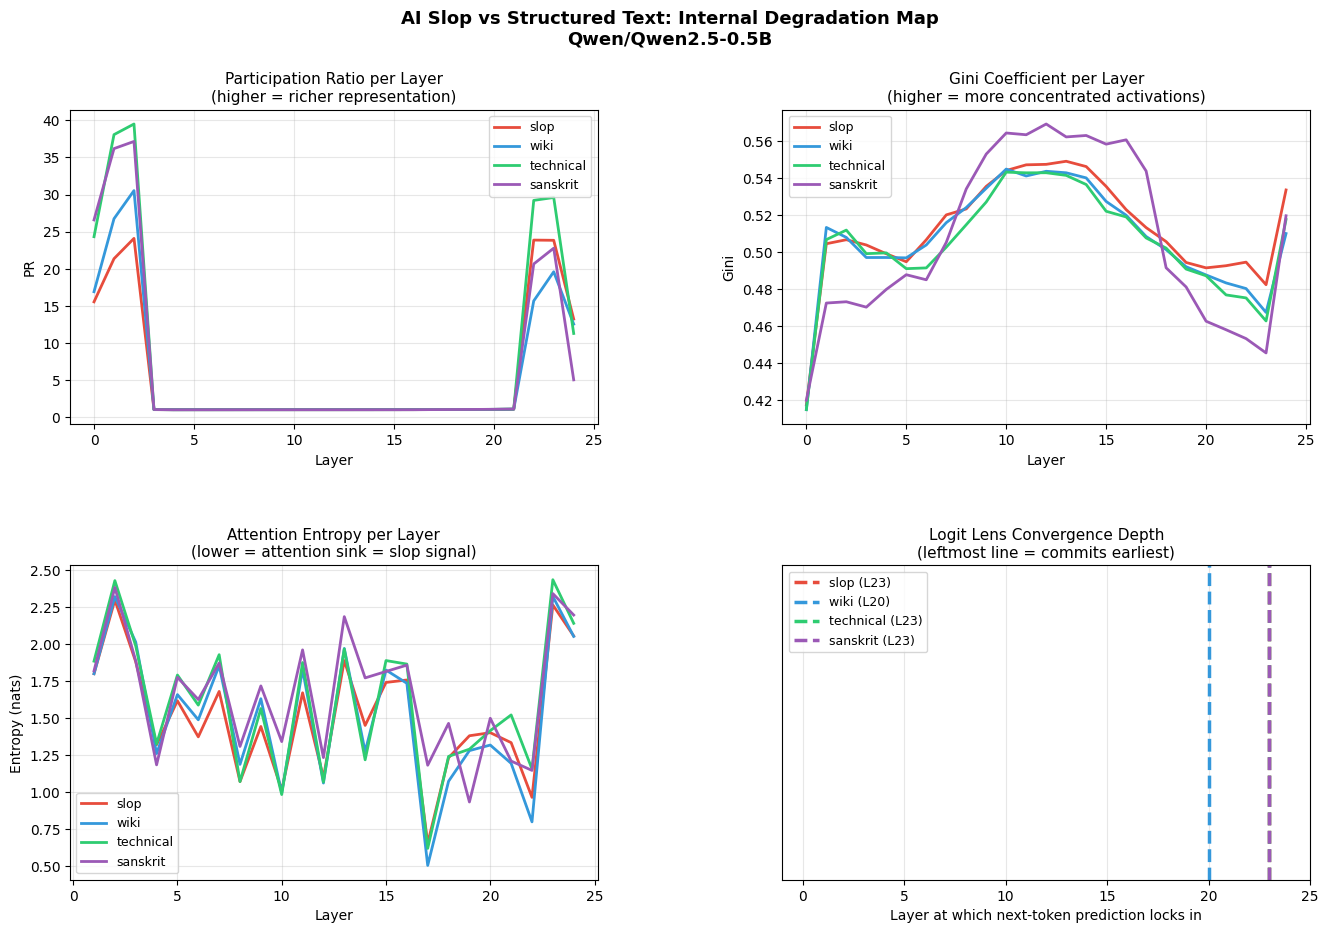

Saved: degradation_map.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

layers  = list(range(n_layers + 1))
a_layers = list(range(1, n_layers + 1))  # attention starts at layer 1
colors  = {
    "slop":      "#e74c3c",
    "wiki":      "#3498db",
    "technical": "#2ecc71",
    "sanskrit":  "#9b59b6",
}

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)
ax_pr   = fig.add_subplot(gs[0, 0])
ax_gini = fig.add_subplot(gs[0, 1])
ax_attn = fig.add_subplot(gs[1, 0])
ax_conv = fig.add_subplot(gs[1, 1])

for name, r in results.items():
    c = colors[name]
    ax_pr.plot(layers,    r["pr"],       label=name, color=c, linewidth=2)
    ax_gini.plot(layers,  r["gini"],     label=name, color=c, linewidth=2)
    ax_attn.plot(a_layers, r["attn_ent"], label=name, color=c, linewidth=2)
    ax_conv.axvline(r["conv"], color=c, linewidth=2.5, linestyle="--",
                    label=f"{name} (L{r['conv']})")

ax_pr.set_title("Participation Ratio per Layer\n(higher = richer representation)", fontsize=11)
ax_pr.set_xlabel("Layer"); ax_pr.set_ylabel("PR")
ax_pr.legend(fontsize=9); ax_pr.grid(alpha=0.3)

ax_gini.set_title("Gini Coefficient per Layer\n(higher = more concentrated activations)", fontsize=11)
ax_gini.set_xlabel("Layer"); ax_gini.set_ylabel("Gini")
ax_gini.legend(fontsize=9); ax_gini.grid(alpha=0.3)

ax_attn.set_title("Attention Entropy per Layer\n(lower = attention sink = slop signal)", fontsize=11)
ax_attn.set_xlabel("Layer"); ax_attn.set_ylabel("Entropy (nats)")
ax_attn.legend(fontsize=9); ax_attn.grid(alpha=0.3)

ax_conv.set_title("Logit Lens Convergence Depth\n(leftmost line = commits earliest)", fontsize=11)
ax_conv.set_xlim(-1, n_layers + 1)
ax_conv.set_xlabel("Layer at which next-token prediction locks in")
ax_conv.set_yticks([])
ax_conv.legend(fontsize=9); ax_conv.grid(axis="x", alpha=0.3)

fig.suptitle(f"AI Slop vs Structured Text: Internal Degradation Map\n{MODEL_ID}",
             fontsize=13, fontweight="bold")
plt.savefig("degradation_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: degradation_map.png")


## Cell 9 — Logit Lens Walkthrough
Show how the predicted next token evolves layer by layer for each text.

In [ ]:
print("Logit lens: predicted next token at last position, layer by layer")
print("Format: L0 -> L1 -> ... -> Ln  (Ln is final prediction)")
print()

with torch.no_grad():
    for name, text in TEXTS.items():
        ids  = tok(text, return_tensors="pt").input_ids.to(DEVICE)
        out  = model(ids)
        states = out.hidden_states
        top1s  = [logit_lens_top1(s.cpu(), unembed, final_norm) for s in states]
        tokens = [repr(tok.decode([t])) for t in top1s]
        conv   = results[name]["conv"]
        print(f"{name:<12}  conv@L{conv:<2}  |  {' -> '.join(tokens)}")


Logit lens: predicted next token at last position, layer by layer
Format: L0 -> L1 -> ... -> Ln  (Ln is final prediction)

slop          conv@L23  |  '.' -> '但如果' -> '换句话' -> '换句话' -> '换句话' -> ' ' -> '/*----------------------------------------------------------------------------' -> ' ' -> '//----------------------------------------------------------------------------------------------------------------' -> '//----------------------------------------------------------------------------------------------------------------' -> '//----------------------------------------------------------------------------------------------------------------' -> 'でしょうね' -> '//----------------------------------------------------------------------------------------------------------------' -> '//----------------------------------------------------------------------------------------------------------------' -> '//-----------------------------------------------------------------------------------------------